# 04 — ML Baseline Models

---

This notebook trains the first baseline machine learning models for match outcome prediction.

## Objectives

The main goal is to verify that the feature-engineering pipeline works end-to-end and to establish the first benchmark results.

In this notebook, we will:

- load the advanced feature dataset,
- select leakage-safe numeric input features,
- create a time-based train/test split,
- fit two baseline models,
- evaluate them using standard multiclass classification metrics.

## Baseline models

The first two baseline models are:

- **Multinomial Logistic Regression**
- **Random Forest**

These models were chosen because they complement each other well:

- Logistic Regression provides a simple and interpretable linear baseline,
- Random Forest provides a stronger non-linear benchmark.

## Important note

This notebook uses a clean **chronological train/test split**.

A more realistic walk-forward evaluation framework will be implemented later in the main modeling notebook.

---

## 1. Imports and setup

We begin by importing libraries and project functions needed for baseline modeling.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR
from src.modeling import (
    select_model_features,
    train_test_split_by_season,
    impute_with_train_medians,
    fit_logistic_regression,
    fit_random_forest,
    evaluate_classifier,
    evaluate_multiple_models,
    get_random_forest_feature_importance,
)

---

## 2. Load the advanced feature dataset

We now load the most complete feature dataset prepared in the previous notebook.

In [2]:
features_path = PROCESSED_DATA_DIR / "match_features_advanced.parquet"

if not features_path.exists():
    features_path = PROCESSED_DATA_DIR / "match_features_advanced.csv"

df = pd.read_parquet(features_path) if features_path.suffix == ".parquet" else pd.read_csv(features_path)
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (882, 249)


,game_id,date,season_id,league_id,home_team_id,away_team_id,home_team,away_team,home_team_code,away_team_code,...,diff_xg_diff_avg_last_8_venue,diff_xg_diff_ewm_span_5_overall,diff_xg_diff_ewm_span_5_venue,diff_xg_for_avg_last_2_overall,diff_xg_for_avg_last_2_venue,diff_xg_for_avg_last_8_overall,diff_xg_for_avg_last_8_venue,diff_xg_for_cum_avg_before,diff_xg_for_ewm_span_5_overall,diff_xg_for_ewm_span_5_venue
0,23065,2023-08-18 18:30:00,2023,3,123,117,Werder Bremen,Bayern Munich,WER,BAY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23066,2023-08-19 13:30:00,2023,3,119,136,Bayer Leverkusen,RasenBallsport Leipzig,LEV,RBL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23067,2023-08-19 13:30:00,2023,3,131,280,Wolfsburg,FC Heidenheim,WOL,HEI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,23068,2023-08-19 13:30:00,2023,3,120,135,Hoffenheim,Freiburg,HOF,FRE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,23069,2023-08-19 13:30:00,2023,3,121,130,Augsburg,Borussia M.Gladbach,AUG,BMG,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

## 3. Inspect the target distribution

Before fitting any model, it is useful to inspect the class distribution of the target variable.

This gives us a first idea of:
- class balance,
- possible difficulty of the draw class,
- and whether accuracy alone may be misleading.

In [3]:
target_distribution = df["target_1x2"].value_counts().rename_axis("class").reset_index(name="count")
target_distribution

,class,count
0,H,371
1,A,286
2,D,225


---
## 4. Select leakage-safe modeling features

The advanced dataset may still contain columns that should not be used as model inputs.

For example:
- identifiers,
- target variables,
- raw match outcomes,
- and direct post-match outcome columns.

We therefore apply an explicit feature-selection step before modeling.

In [4]:
X_all, feature_cols = select_model_features(df)
y_all = df["target_1x2"].copy()

print("Number of selected numeric features:", len(feature_cols))
display(feature_cols[:30])

Number of selected numeric features: 219


['home_elo_pre',
 'away_elo_pre',
 'elo_diff_pre',
 'home_rest_days',
 'home_goals_for_avg_last_2_overall',
 'home_goals_for_avg_last_8_overall',
 'home_goals_against_avg_last_2_overall',
 'home_goals_against_avg_last_8_overall',
 'home_xg_for_avg_last_2_overall',
 'home_xg_for_avg_last_8_overall',
 'home_xg_against_avg_last_2_overall',
 'home_xg_against_avg_last_8_overall',
 'home_np_xg_for_avg_last_2_overall',
 'home_np_xg_for_avg_last_8_overall',
 'home_np_xg_against_avg_last_2_overall',
 'home_np_xg_against_avg_last_8_overall',
 'home_expected_points_avg_last_2_overall',
 'home_expected_points_avg_last_8_overall',
 'home_ppda_avg_last_2_overall',
 'home_ppda_avg_last_8_overall',
 'home_deep_completions_avg_last_2_overall',
 'home_deep_completions_avg_last_8_overall',
 'home_points_avg_last_2_overall',
 'home_points_avg_last_8_overall',
 'home_goal_diff_avg_last_2_overall',
 'home_goal_diff_avg_last_8_overall',
 'home_xg_diff_avg_last_2_overall',
 'home_xg_diff_avg_last_8_overall',


---

## 5. Create a chronological train/test split

For the first baseline experiment, we use a simple time-based split.

Training data include older matches, while testing data include the most recent period.

This is not yet the final walk-forward setup, but it already respects time ordering and avoids random leakage.

In [5]:
train_df, test_df = train_test_split_by_season(
    df=df,
    train_seasons=[2023, 2024],
    test_seasons=[2025],
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train seasons:", sorted(train_df["season_id"].unique()))
print("Test seasons:", sorted(test_df["season_id"].unique()))
print("Train period:", train_df["date"].min(), "->", train_df["date"].max())
print("Test period:", test_df["date"].min(), "->", test_df["date"].max())

Train shape: (612, 249)
Test shape: (270, 249)
Train seasons: [2023, 2024]
Test seasons: [2025]
Train period: 2023-08-18 18:30:00 -> 2025-05-17 13:30:00
Test period: 2025-08-22 18:30:00 -> 2026-04-19 17:30:00


---

## 6. Build train and test matrices

We now extract the selected features and target variables for the train and test periods.

In [6]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df["target_1x2"].copy()
y_test = test_df["target_1x2"].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (612, 219)
X_test shape: (270, 219)
y_train shape: (612,)
y_test shape: (270,)


---

## 7. Handle missing values

Some advanced features naturally contain missing values, especially:
- at the beginning of the dataset,
- at the start of each season,
- or when there is not enough home-only / away-only history.

For the baseline models, we use a simple and transparent strategy:
- compute medians on the training set,
- fill missing values in both train and test sets using those training medians.

In [7]:
X_train, X_test, train_medians = impute_with_train_medians(X_train, X_test)

print("Remaining missing values in X_train:", int(X_train.isna().sum().sum()))
print("Remaining missing values in X_test:", int(X_test.isna().sum().sum()))

Remaining missing values in X_train: 0
Remaining missing values in X_test: 0


## 8. Train baseline model 1 — multinomial logistic regression

This model provides a strong linear baseline for multiclass football outcome prediction.

In [8]:
logit_model = fit_logistic_regression(X_train, y_train)
logit_results = evaluate_classifier(logit_model, X_test, y_test)

print("Logistic Regression — classification report")
print(logit_results["classification_report"])

Logistic Regression — classification report
              precision    recall  f1-score   support

           A       0.40      0.51      0.45        85
           D       0.29      0.33      0.31        66
           H       0.57      0.42      0.49       119

    accuracy                           0.43       270
   macro avg       0.42      0.42      0.41       270
weighted avg       0.45      0.43      0.43       270



C:\Users\cerve\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


---

## 9. Train baseline model 2 — random forest

Random Forest provides a non-linear benchmark and can capture interactions between features.

In [9]:
rf_model = fit_random_forest(X_train, y_train)
rf_results = evaluate_classifier(rf_model, X_test, y_test)

print("Random Forest — classification report")
print(rf_results["classification_report"])

Random Forest — classification report
              precision    recall  f1-score   support

           A       0.47      0.71      0.56        85
           D       0.36      0.26      0.30        66
           H       0.65      0.52      0.58       119

    accuracy                           0.51       270
   macro avg       0.49      0.49      0.48       270
weighted avg       0.52      0.51      0.51       270



---

## 10. Compare baseline model performance

We now summarize the baseline results in a compact comparison table.



In [10]:
baseline_results = {
    "logistic_regression": logit_results,
    "random_forest": rf_results,
}

results_table = evaluate_multiple_models(baseline_results)
results_table

,model,accuracy,macro_f1,weighted_f1
0,random_forest,0.514815,0.481235,0.506293
1,logistic_regression,0.425926,0.414404,0.430706


---

## 11. Confusion matrix — logistic regression

Confusion matrices help reveal which outcomes are hardest to classify.

In football match prediction, the draw class is often the most difficult one.

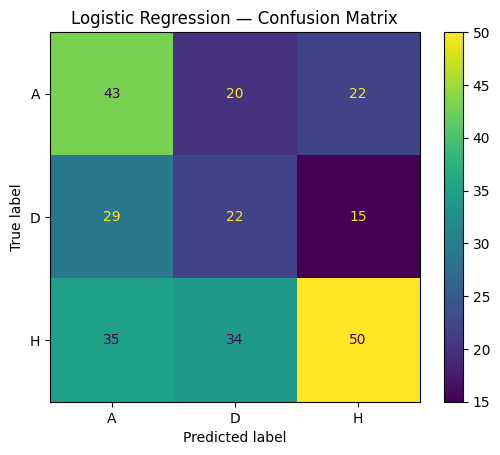

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=logit_results["confusion_matrix"],
    display_labels=logit_model.classes_,
)
disp.plot()
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

---

## 12. Confusion matrix — random forest

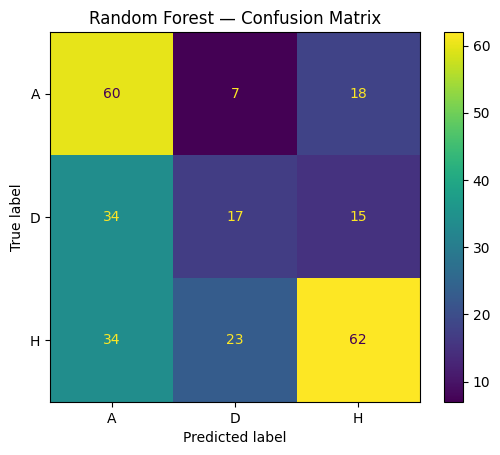

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_results["confusion_matrix"],
    display_labels=rf_model.classes_,
)
disp.plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

---

## 13. Feature importance from Random Forest

Although this is still only a baseline experiment, Random Forest can already provide a first indication of which predictors appear most useful.

In [13]:
rf_importance = get_random_forest_feature_importance(rf_model, feature_cols)
rf_importance.head(20)

,feature,importance
0,diff_expected_points_cum_avg_before,0.015493
1,home_expected_points_cum_avg_before,0.012587
2,diff_expected_points_avg_last_8_venue,0.010687
3,diff_deep_completions_cum_avg_before,0.010427
4,diff_np_xg_diff_avg_last_8_overall,0.010298
5,diff_xg_diff_avg_last_8_overall,0.010067
6,diff_expected_points_avg_last_8_overall,0.009763
7,diff_np_xg_for_cum_avg_before,0.009724
8,home_np_xg_for_cum_avg_before,0.009631
9,diff_xg_for_avg_last_8_venue,0.009500


---

## 14. Baseline conclusions

This notebook established the first machine-learning benchmark for the project.

### Main outcomes

- the advanced feature dataset was successfully used for prediction,
- a leakage-safe baseline modeling pipeline was built,
- two baseline models were trained and evaluated,
- the first benchmark metrics were obtained.

### Interpretation

At this stage, the main purpose is not to maximize predictive performance, but to verify that:

- the pipeline works end-to-end,
- the features appear informative,
- the class structure is sensible,
- and the project is ready for the full ML modeling stage.

### Next step

The next notebook will extend this baseline by:

- including the full set of ML methods described in the thesis,
- adding feature selection,
- tuning hyperparameters,
- and implementing a more realistic evaluation framework.